In [3]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from langchain_core.messages import SystemMessage,HumanMessage,BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph,START,END
from llm import llm

In [4]:
def node1(state: MessagesState):
    response=llm.invoke(state["messages"])
    return{"messages":response}

In [5]:
graph=StateGraph(MessagesState)
graph.add_node("ai",node1)


In [6]:
graph.set_entry_point("ai")
graph.set_finish_point("ai")

In [7]:
State_graph=graph.compile()

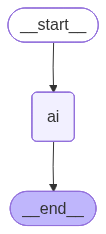

In [8]:
State_graph

In [9]:
response=State_graph.invoke(
    {
        "messages":[HumanMessage(content="what is capital of india?")]
    }
)

In [10]:
for message in response["messages"]:
    print(message.content)

what is capital of india?
The capital of India is **New Delhi**.
